In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

***Data Load***

In [3]:
dataset_path = r"E:\CSE499A\Project Code\Data Preprocessing\Master Dataset\RSM_Dataset.csv"
df = pd.read_csv(dataset_path, dtype={'sku': str})

In [4]:
df.head()

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,3285085,62.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
1,3285131,9.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,No,No,Yes,No,No,No
2,3285358,17.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.92,0.95,0.0,No,No,No,Yes,No,No
3,3285517,9.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.78,0.75,0.0,No,No,Yes,Yes,No,No
4,3285608,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.54,0.71,0.0,No,No,No,Yes,No,No


In [5]:
df.tail()

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
1929931,1407754,0.0,2.0,0.0,10.0,10.0,10.0,0.0,5.0,7.0,...,0.0,0.69,0.69,5.0,Yes,No,No,Yes,No,No
1929932,1373987,-1.0,NaN,0.0,5.0,7.0,9.0,1.0,3.0,3.0,...,0.0,-99.00,-99.00,1.0,No,No,No,Yes,No,No
1929933,1524346,-1.0,9.0,0.0,7.0,9.0,11.0,0.0,8.0,11.0,...,0.0,0.86,0.84,1.0,Yes,No,No,No,No,Yes
1929934,1439563,62.0,9.0,16.0,39.0,87.0,126.0,35.0,63.0,153.0,...,0.0,0.86,0.84,6.0,No,No,No,Yes,No,No
1929935,1502009,19.0,4.0,0.0,0.0,0.0,0.0,2.0,7.0,12.0,...,0.0,0.73,0.78,1.0,No,No,No,Yes,No,No


***Data Preprocessing***

In [6]:
df.shape

(1929936, 23)

In [7]:
df.dtypes

sku                      str
national_inv         float64
lead_time            float64
in_transit_qty       float64
forecast_3_month     float64
forecast_6_month     float64
forecast_9_month     float64
sales_1_month        float64
sales_3_month        float64
sales_6_month        float64
sales_9_month        float64
min_bank             float64
potential_issue          str
pieces_past_due      float64
perf_6_month_avg     float64
perf_12_month_avg    float64
local_bo_qty         float64
deck_risk                str
oe_constraint            str
ppap_risk                str
stop_auto_buy            str
rev_stop                 str
went_on_backorder        str
dtype: object

***Sanity Check***

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1929936 entries, 0 to 1929935
Data columns (total 23 columns):
 #   Column             Dtype  
---  ------             -----  
 0   sku                str    
 1   national_inv       float64
 2   lead_time          float64
 3   in_transit_qty     float64
 4   forecast_3_month   float64
 5   forecast_6_month   float64
 6   forecast_9_month   float64
 7   sales_1_month      float64
 8   sales_3_month      float64
 9   sales_6_month      float64
 10  sales_9_month      float64
 11  min_bank           float64
 12  potential_issue    str    
 13  pieces_past_due    float64
 14  perf_6_month_avg   float64
 15  perf_12_month_avg  float64
 16  local_bo_qty       float64
 17  deck_risk          str    
 18  oe_constraint      str    
 19  ppap_risk          str    
 20  stop_auto_buy      str    
 21  rev_stop           str    
 22  went_on_backorder  str    
dtypes: float64(15), str(8)
memory usage: 381.3 MB


***Finding missing values***

In [9]:
df.isnull().sum()

sku                       0
national_inv              1
lead_time            115618
in_transit_qty            1
forecast_3_month          1
forecast_6_month          1
forecast_9_month          1
sales_1_month             1
sales_3_month             1
sales_6_month             1
sales_9_month             1
min_bank                  1
potential_issue           1
pieces_past_due           1
perf_6_month_avg          1
perf_12_month_avg         1
local_bo_qty              1
deck_risk                 1
oe_constraint             1
ppap_risk                 1
stop_auto_buy             1
rev_stop                  1
went_on_backorder         1
dtype: int64

In [10]:
df.isnull().sum()/df.shape[0]*100

sku                  0.000000
national_inv         0.000052
lead_time            5.990769
in_transit_qty       0.000052
forecast_3_month     0.000052
forecast_6_month     0.000052
forecast_9_month     0.000052
sales_1_month        0.000052
sales_3_month        0.000052
sales_6_month        0.000052
sales_9_month        0.000052
min_bank             0.000052
potential_issue      0.000052
pieces_past_due      0.000052
perf_6_month_avg     0.000052
perf_12_month_avg    0.000052
local_bo_qty         0.000052
deck_risk            0.000052
oe_constraint        0.000052
ppap_risk            0.000052
stop_auto_buy        0.000052
rev_stop             0.000052
went_on_backorder    0.000052
dtype: float64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
for i in df.select_dtypes(include=['object']):
    print(df[i].value_counts())
    print("*" * 100)

C:\Users\User\AppData\Local\Temp\ipykernel_2676\380422911.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for i in df.select_dtypes(include=['object']):


sku
3285085    1
3285131    1
3285358    1
3285517    1
3285608    1
          ..
1407754    1
1373987    1
1524346    1
1439563    1
1502009    1
Name: count, Length: 1929936, dtype: int64
****************************************************************************************************
potential_issue
No     1928946
Yes        989
Name: count, dtype: int64
****************************************************************************************************
deck_risk
No     1494482
Yes     435453
Name: count, dtype: int64
****************************************************************************************************
oe_constraint
No     1929643
Yes        292
Name: count, dtype: int64
****************************************************************************************************
ppap_risk
No     1697383
Yes     232552
Name: count, dtype: int64
****************************************************************************************************
stop_auto_buy
Yes    1859391
No

***Exploratory Data Analysis (EDA)***

In [13]:
df.describe()

,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty
count,1.929935e+06,1.814318e+06,1.929935e+06,1.929935e+06,1.929935e+06,1.929935e+06,1.929935e+06,1.929935e+06,1.929935e+06,1.929935e+06,1.929935e+06,1.929935e+06,1.929935e+06,1.929935e+06,1.929935e+06
mean,4.965683e+02,7.878627e+00,4.306440e+01,1.785399e+02,3.454659e+02,5.066067e+02,5.536816e+01,1.746639e+02,3.415653e+02,5.235771e+02,5.277637e+01,2.016193e+00,-6.899870e+00,-6.462343e+00,6.537039e-01
std,2.957343e+04,7.054212e+00,1.295420e+03,5.108770e+03,9.831562e+03,1.434543e+04,1.884377e+03,5.188856e+03,9.585030e+03,1.473327e+04,1.257968e+03,2.296112e+02,2.659988e+01,2.588343e+01,3.543230e+01
min,-2.725600e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.900000e+01,-9.900000e+01,0.000000e+00
25%,4.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.300000e-01,6.600000e-01,0.000000e+00
50%,1.500000e+01,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,8.200000e-01,8.100000e-01,0.000000e+00
75%,8.000000e+01,9.000000e+00,0.000000e+00,4.000000e+00,1.200000e+01,2.000000e+01,4.000000e+00,1.500000e+01,3.100000e+01,4.700000e+01,3.000000e+00,0.000000e+00,9.600000e-01,9.500000e-01,0.000000e+00
max,1.233440e+07,5.200000e+01,4.894080e+05,1.510592e+06,2.461360e+06,3.777304e+06,7.417740e+05,1.105478e+06,2.146625e+06,3.205172e+06,3.133190e+05,1.464960e+05,1.000000e+00,1.000000e+00,1.253000e+04


***description of object column***

In [14]:

df.describe(include='object')

C:\Users\User\AppData\Local\Temp\ipykernel_2676\1475251020.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,sku,potential_issue,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
count,1929936,1929935,1929935,1929935,1929935,1929935,1929935,1929935
unique,1929936,2,2,2,2,2,2,2
top,3285085,No,No,No,No,Yes,No,No
freq,1,1928946,1494482,1929643,1697383,1859391,1929096,1915954


***Ploting Boxplot***

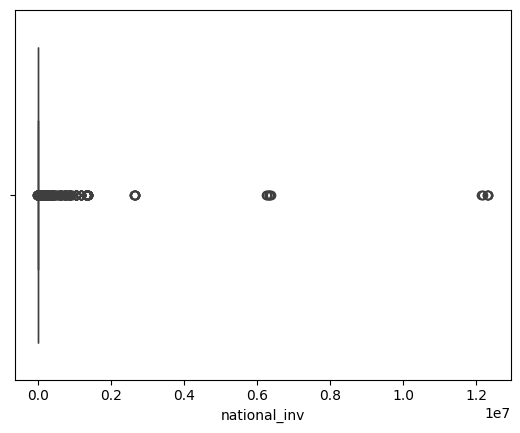

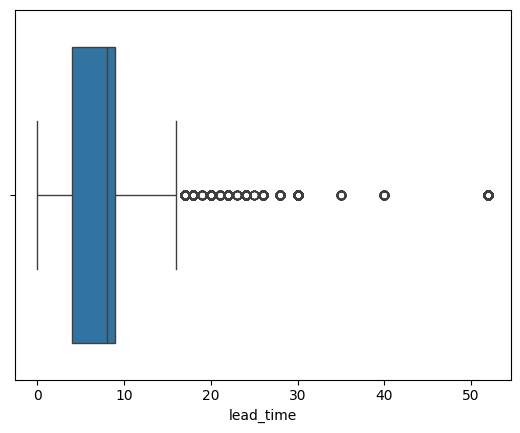

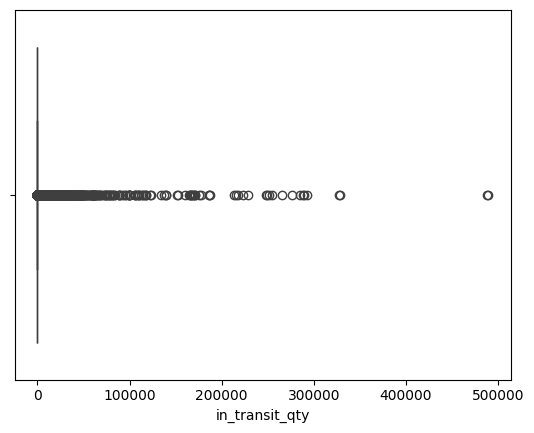

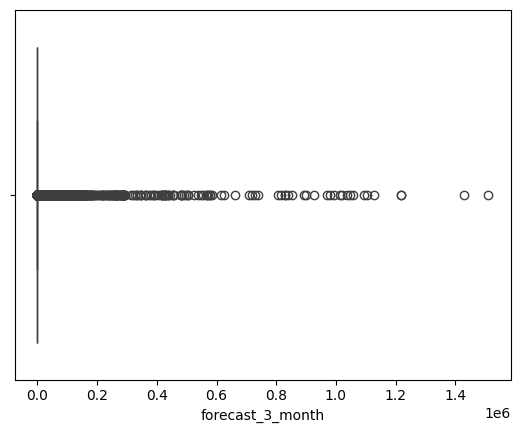

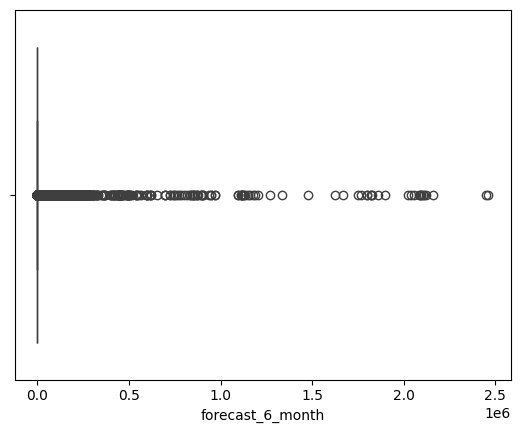

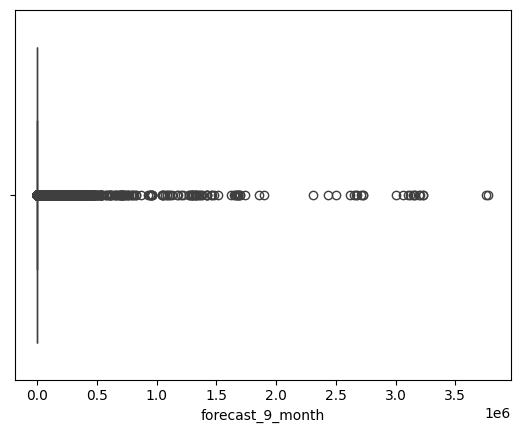

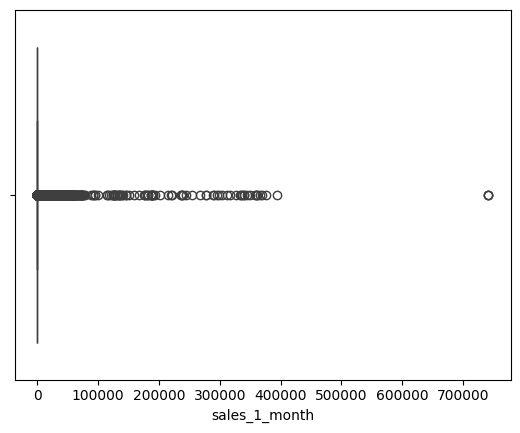

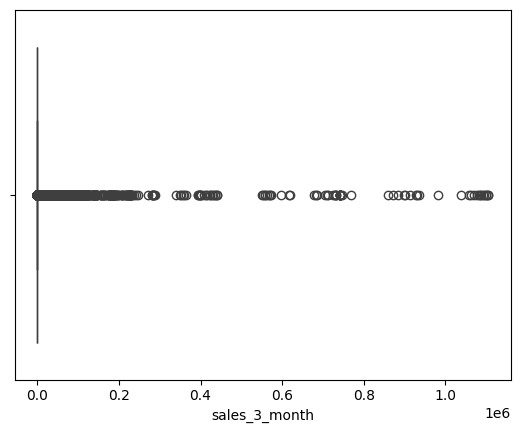

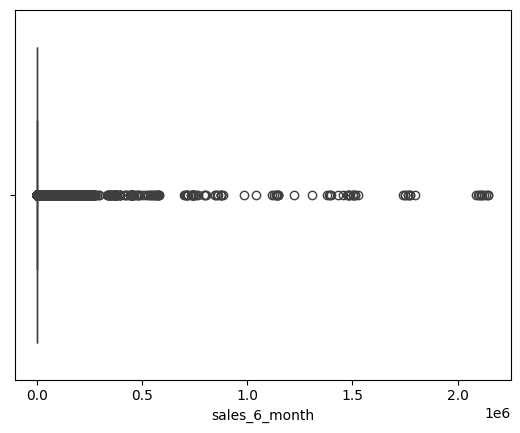

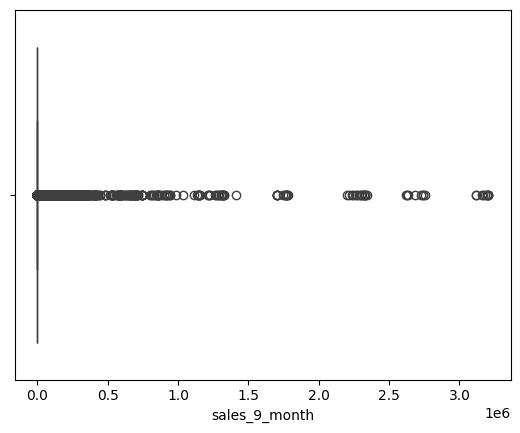

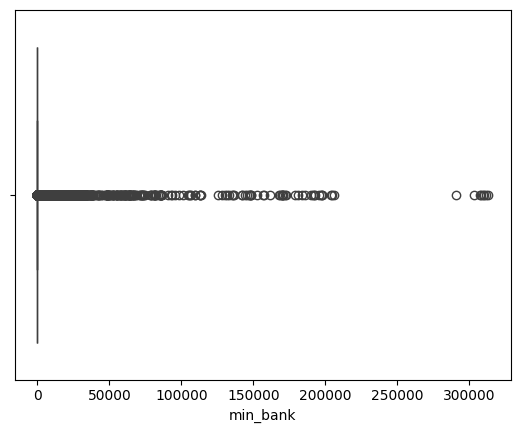

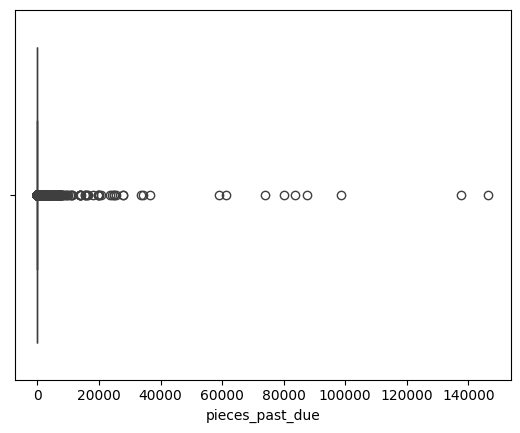

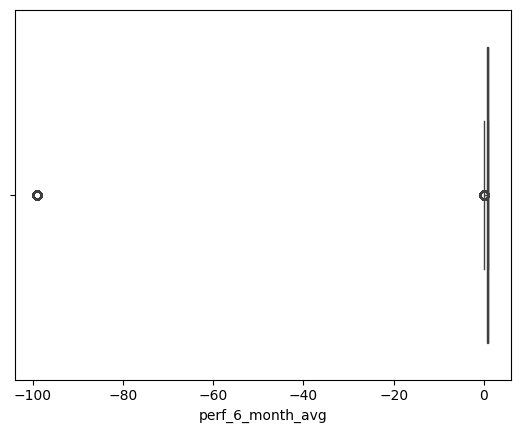

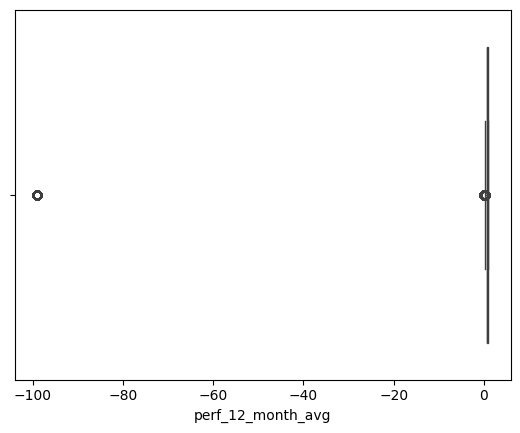

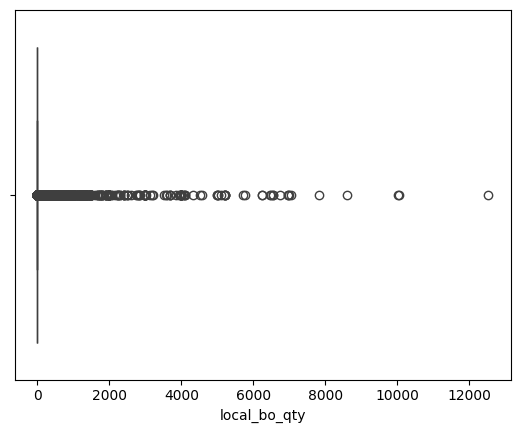

In [15]:
for i in df.select_dtypes(include="number").columns:
  sns.boxplot(data=df,x=i)
  plt.show()

***Correlation***

In [16]:
df.select_dtypes(include="number").corr()

,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty
national_inv,1.000000,0.003332,0.098473,0.080034,0.081328,0.080423,0.155753,0.191604,0.224305,0.239924,0.405298,0.030307,-0.013742,-0.010686,0.012814
lead_time,0.003332,1.000000,-0.007374,-0.007894,-0.008473,-0.008734,-0.006179,-0.007274,-0.007307,-0.007337,-0.008164,-0.001554,-0.099056,-0.105301,-0.001622
in_transit_qty,0.098473,-0.007374,1.000000,0.638241,0.667614,0.661650,0.622062,0.687824,0.676524,0.645470,0.742187,0.161349,0.003169,0.004246,0.063223
forecast_3_month,0.080034,-0.007894,0.638241,1.000000,0.988112,0.971443,0.688490,0.764681,0.817126,0.809634,0.719626,0.359632,0.008378,0.008613,0.043872
forecast_6_month,0.081328,-0.008473,0.667614,0.988112,1.000000,0.994281,0.709730,0.799705,0.858822,0.852034,0.736929,0.367494,0.008346,0.008501,0.044063
forecast_9_month,0.080423,-0.008734,0.661650,0.971443,0.994281,1.000000,0.725149,0.823402,0.885969,0.879327,0.735548,0.373258,0.008348,0.008464,0.044010
sales_1_month,0.155753,-0.006179,0.622062,0.688490,0.709730,0.725149,1.000000,0.918282,0.873111,0.824634,0.769847,0.260607,0.001037,0.002315,0.065749
sales_3_month,0.191604,-0.007274,0.687824,0.764681,0.799705,0.823402,0.918282,1.000000,0.975437,0.930531,0.854285,0.314536,0.001371,0.002769,0.068080
sales_6_month,0.224305,-0.007307,0.676524,0.817126,0.858822,0.885969,0.873111,0.975437,1.000000,0.973871,0.838836,0.334398,0.002761,0.004148,0.056219
sales_9_month,0.239924,-0.007337,0.645470,0.809634,0.852034,0.879327,0.824634,0.930531,0.973871,1.000000,0.804336,0.329906,0.003325,0.004704,0.048616


***Ploting Heat Map***

<Axes: >

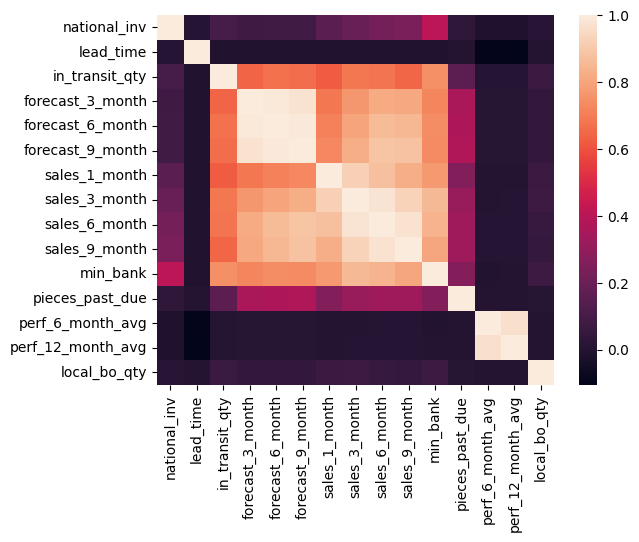

In [17]:
s = df.select_dtypes(include="number").corr()
sns.heatmap(s)

***Missing Value Treatment***

In [18]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error

***Handling Negative values***

In [19]:
perf_columns = ['perf_6_month_avg', 'perf_12_month_avg']

In [20]:
for col in perf_columns:
    df[col] = df[col].mask(df[col] < 0)

In [21]:
for col in perf_columns:
    nan_count = df[col].isna().sum()
    print(f"Column '{col}' now has {nan_count} NaN values (cleaned from negatives).")

Column 'perf_6_month_avg' now has 148580 NaN values (cleaned from negatives).
Column 'perf_12_month_avg' now has 140026 NaN values (cleaned from negatives).


***Fill NaN values of perf_6_month_avg and perf_12_month_avg***

In [22]:
from sklearn.impute import SimpleImputer

In [23]:
perf_cols = ['perf_6_month_avg', 'perf_12_month_avg']

In [24]:
imputer = SimpleImputer(strategy='median')

In [25]:
df[perf_cols] = imputer.fit_transform(df[perf_cols])

***Binary Encoding***

In [26]:
from sklearn.preprocessing import OrdinalEncoder

In [27]:
binary_cols = ['deck_risk', 'ppap_risk', 'stop_auto_buy', 'potential_issue']

In [28]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

In [29]:
df[binary_cols] = encoder.fit_transform(df[binary_cols].astype(str))

***Feature Engineering***

In [30]:
safe_inv = df['national_inv'].clip(lower=0)
df['inv_velocity'] = df['sales_1_month'] / (safe_inv + 1)
df['safety_gap'] = df['national_inv'] - df['min_bank']
df['sales_trend'] = df['sales_1_month'] / ((df['sales_3_month'] / 3) + 1)
df['perf_gap'] = (df['perf_6_month_avg'] - df['perf_12_month_avg']).abs()

In [31]:
df.shape

(1929936, 27)

***Building Mini Machine Learning Model***

In [32]:
features = [
    'national_inv', 'in_transit_qty', 'sales_1_month',
    'sales_3_month', 'min_bank', 'perf_6_month_avg',
    'deck_risk', 'ppap_risk', 'stop_auto_buy',
    'inv_velocity', 'safety_gap', 'sales_trend', 'perf_gap'
]

In [33]:
df_known = df[df['lead_time'].notna()]
df_missing = df[df['lead_time'].isna()]

In [34]:
print(f"Training on {len(df_known)} rows to predict {len(df_missing)} missing rows...")

Training on 1814318 rows to predict 115618 missing rows...


In [35]:
X_train = df_known[features]
y_train = df_known['lead_time']

***Hyper Parameter Tuning***

In [36]:
#don't need to run
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error

In [37]:
#don't need to run
param_grid = {
    'max_iter': [200, 300, 400],
    'max_depth': [10, 15, 20, None],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_regularization': [0.0, 1.0, 2.0],
    'min_samples_leaf': [20, 50, 100]
}

In [ ]:
#don't need to run
tuner = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=10,          # Tests 10 random combinations
    scoring='neg_root_mean_squared_error',
    cv=3,               # Tests each combination 3 times
    verbose=2,          # Prints updates so you know it's working
    random_state=42,
    n_jobs=-1           # Uses all CPU cores
)

In [ ]:
#don't need to run
imputer_model = tuner.best_estimator_

In [38]:
imputer_model = HistGradientBoostingRegressor(
    min_samples_leaf=50,
    max_iter=400,
    max_depth=15,
    learning_rate=0.1,
    l2_regularization=1.0
)

In [39]:
imputer_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",400
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",15
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",50
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",1.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.

In [40]:
#after parameter tuning
predictions_train = imputer_model.predict(X_train)
rmse = np.sqrt(mean_squared_error(y_train, predictions_train))

In [41]:
rmse = np.sqrt(mean_squared_error(y_train, predictions_train))

In [ ]:
#don't need to run
print(f"Best Parameters Found: {tuner.best_params_}")
print(f"🎉 Champion Model Training RMSE: +/- {rmse:.8f} days")

In [42]:
predictions_train = imputer_model.predict(X_train)
rmse = np.sqrt(mean_squared_error(y_train, predictions_train))
print(f"Model Error Margin (RMSE): +/- {rmse:.8f} days")

Model Error Margin (RMSE): +/- 4.87044200 days


***Feature Importance Check xx***

In [ ]:
#don't need to run
from sklearn.inspection import permutation_importance

In [ ]:
#don't need to run
result = permutation_importance(imputer_model, X_train, y_train, n_repeats=5, random_state=42)

In [ ]:
#don't need to run
importance_leaderboard = pd.DataFrame({
    'Feature': [
    'national_inv', 'in_transit_qty', 'sales_1_month',
    'sales_3_month', 'min_bank', 'perf_6_month_avg',
    'deck_risk', 'ppap_risk', 'stop_auto_buy', 'potential_issue',
    'inv_velocity', 'safety_gap', 'sales_trend', 'perf_gap'
], 
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

In [ ]:
#don't need to run
print("\n🏆 FEATURE IMPORTANCE LEADERBOARD 🏆")
print(importance_leaderboard)

***Filling up the missing lead_time value with imputer model***

In [43]:
X_missing = df_missing[features]

In [44]:
print(f"🔮 Predicting lead times for {len(X_missing)} missing rows...")
predicted_lead_times = imputer_model.predict(X_missing)

🔮 Predicting lead times for 115618 missing rows...


In [45]:
#injecting the values of lead_time
df.loc[df['lead_time'].isna(), 'lead_time'] = predicted_lead_times

In [46]:
remaining_missing = df['lead_time'].isna().sum()
print(f"🎉 Remaining missing lead_times in main df: {remaining_missing}")

🎉 Remaining missing lead_times in main df: 0


In [47]:

df = df.dropna(subset=['went_on_backorder'])


print("Missing values after cleanup:")
print(df.isnull().sum())

Missing values after cleanup:
sku                  0
national_inv         0
lead_time            0
in_transit_qty       0
forecast_3_month     0
forecast_6_month     0
forecast_9_month     0
sales_1_month        0
sales_3_month        0
sales_6_month        0
sales_9_month        0
min_bank             0
potential_issue      0
pieces_past_due      0
perf_6_month_avg     0
perf_12_month_avg    0
local_bo_qty         0
deck_risk            0
oe_constraint        0
ppap_risk            0
stop_auto_buy        0
rev_stop             0
went_on_backorder    0
inv_velocity         0
safety_gap           0
sales_trend          0
perf_gap             0
dtype: int64


In [48]:
df.columns

Index(['sku', 'national_inv', 'lead_time', 'in_transit_qty',
       'forecast_3_month', 'forecast_6_month', 'forecast_9_month',
       'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month',
       'min_bank', 'potential_issue', 'pieces_past_due', 'perf_6_month_avg',
       'perf_12_month_avg', 'local_bo_qty', 'deck_risk', 'oe_constraint',
       'ppap_risk', 'stop_auto_buy', 'rev_stop', 'went_on_backorder',
       'inv_velocity', 'safety_gap', 'sales_trend', 'perf_gap'],
      dtype='str')

In [49]:
df['went_on_backorder']

0           No
1           No
2           No
3           No
4           No
          ... 
1929931     No
1929932     No
1929933    Yes
1929934     No
1929935     No
Name: went_on_backorder, Length: 1929935, dtype: str

***Encoding***

In [68]:
#Turning sku into index 
if 'sku' in df.columns:
    df.set_index('sku', inplace=True)

In [69]:
cols_to_fix = ['went_on_backorder', 'oe_constraint', 'rev_stop']

In [70]:
binary_map = {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0}

In [71]:
for col in cols_to_fix:
    if col in df.columns:
        df[col] = df[col].map(binary_map)
        print(f"🔢 Encoded: {col}")

🔢 Encoded: went_on_backorder
🔢 Encoded: oe_constraint
🔢 Encoded: rev_stop


***Changing Dtypes***

In [50]:
binary_cols = [
    'deck_risk', 'ppap_risk', 'stop_auto_buy', 'potential_issue'
]

In [51]:
for col in binary_cols:
    if col in df.columns:
        
        df[col] = df[col].fillna(0).astype(int)
        print(f"✅ {col} is now type: {df[col].dtype}")

✅ deck_risk is now type: int64
✅ ppap_risk is now type: int64
✅ stop_auto_buy is now type: int64
✅ potential_issue is now type: int64


In [52]:
df.dtypes

sku                      str
national_inv         float64
lead_time            float64
in_transit_qty       float64
forecast_3_month     float64
forecast_6_month     float64
forecast_9_month     float64
sales_1_month        float64
sales_3_month        float64
sales_6_month        float64
sales_9_month        float64
min_bank             float64
potential_issue        int64
pieces_past_due      float64
perf_6_month_avg     float64
perf_12_month_avg    float64
local_bo_qty         float64
deck_risk              int64
oe_constraint            str
ppap_risk              int64
stop_auto_buy          int64
rev_stop                 str
went_on_backorder        str
inv_velocity         float64
safety_gap           float64
sales_trend          float64
perf_gap             float64
dtype: object

***Memory***

In [53]:
mem_before = df.memory_usage().sum() / 1024**2
print(f"📦 Memory usage BEFORE: {mem_before:.2f} MB")

📦 Memory usage BEFORE: 437.14 MB


In [54]:
floats = df.select_dtypes(include=['float64']).columns
df[floats] = df[floats].astype('float32')

In [55]:
ints = df.select_dtypes(include=['int64']).columns
df[ints] = df[ints].astype('int32')

In [56]:
mem_after = df.memory_usage().sum() / 1024**2
print(f"🚀 Memory usage AFTER: {mem_after:.2f} MB")
print(f"📉 Total Reduction: {((mem_before - mem_after) / mem_before) * 100:.1f}%")

🚀 Memory usage AFTER: 267.81 MB
📉 Total Reduction: 38.7%


In [57]:
df.dtypes

sku                      str
national_inv         float32
lead_time            float32
in_transit_qty       float32
forecast_3_month     float32
forecast_6_month     float32
forecast_9_month     float32
sales_1_month        float32
sales_3_month        float32
sales_6_month        float32
sales_9_month        float32
min_bank             float32
potential_issue        int32
pieces_past_due      float32
perf_6_month_avg     float32
perf_12_month_avg    float32
local_bo_qty         float32
deck_risk              int32
oe_constraint            str
ppap_risk              int32
stop_auto_buy          int32
rev_stop                 str
went_on_backorder        str
inv_velocity         float32
safety_gap           float32
sales_trend          float32
perf_gap             float32
dtype: object

In [58]:
df.tail(20)

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder,inv_velocity,safety_gap,sales_trend,perf_gap
1929916,1547033,-47.0,12.000000,49.0,249.0,249.0,249.0,0.0,180.0,187.0,...,0,No,0,1,No,No,0.000000,-47.0,0.000000,0.00
1929917,1413443,688.0,4.000000,280.0,690.0,1540.0,2190.0,314.0,1042.0,1819.0,...,0,No,0,1,No,No,0.455733,463.0,0.901435,0.02
1929918,1368348,25.0,8.000000,16.0,135.0,180.0,255.0,44.0,98.0,160.0,...,0,No,0,1,No,No,1.692308,-26.0,1.306931,0.02
1929919,1409190,-1.0,3.000000,18.0,0.0,0.0,0.0,5.0,8.0,8.0,...,1,No,0,1,No,No,5.000000,-1.0,1.363636,0.15
1929920,1529626,488.0,2.000000,201.0,720.0,1400.0,2160.0,248.0,665.0,1265.0,...,0,No,0,1,No,No,0.507157,299.0,1.113773,0.03
1929921,1375433,4113.0,4.000000,2015.0,2871.0,6200.0,7909.0,944.0,3388.0,9471.0,...,0,No,0,1,No,No,0.229460,3317.0,0.835152,0.05
1929922,1497988,-3.0,12.000000,0.0,128.0,179.0,230.0,97.0,181.0,296.0,...,0,No,0,1,No,No,97.000000,-3.0,1.581522,0.01
1929923,1375861,-206.0,16.480534,0.0,760.0,1145.0,1453.0,114.0,853.0,1764.0,...,1,No,0,1,No,No,114.000000,-206.0,0.399533,0.02
1929924,1573563,39.0,8.000000,5.0,88.0,119.0,140.0,17.0,57.0,113.0,...,0,No,0,1,No,No,0.425000,14.0,0.850000,0.00
1929925,1460296,2707.0,2.000000,830.0,9000.0,18000.0,26500.0,2011.0,6998.0,15074.0,...,0,No,0,1,No,No,0.742614,761.0,0.861734,0.01


***Saving the processed dataset***

In [59]:
df.to_pickle('Processed_Dataset_with_SKU_Column.pkl')

In [60]:
df.to_csv('Processed_Dataset_with_SKU_Column.csv', index=False)

In [76]:
df_sp = pd.read_pickle('Processed_Dataset_with_SKU_Column.pkl')

In [62]:
df_2sc = pd.read_csv('Processed_Dataset_with_SKU_Column.csv', dtype={'sku': str})

In [75]:
df_2sc.head(20)

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder,inv_velocity,safety_gap,sales_trend,perf_gap
0,3285085,62.0,24.838926,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,No,0,1,No,No,0.0,61.0,0.0,0.02
1,3285131,9.0,7.937768,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,No,1,0,No,No,0.0,8.0,0.0,0.02
2,3285358,17.0,8.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,No,0,1,No,No,0.0,17.0,0.0,0.03
3,3285517,9.0,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,No,1,1,No,No,0.0,9.0,0.0,0.03
4,3285608,2.0,8.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,No,0,1,No,No,0.0,2.0,0.0,0.17
5,3285960,15.0,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0,No,0,1,No,No,0.0,15.0,0.0,0.31
6,3286073,0.0,7.783297,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,No,0,1,No,No,0.0,0.0,0.0,0.02
7,3286113,28.0,21.335035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,No,0,1,No,No,0.0,28.0,0.0,0.02
8,3286206,2.0,11.092326,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,No,1,1,No,No,0.0,2.0,0.0,0.02
9,3286325,2.0,8.802704,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,No,0,1,No,No,0.0,2.0,0.0,0.02


In [77]:
df_sp.head(20)

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder,inv_velocity,safety_gap,sales_trend,perf_gap
0,3285085,62.0,24.838926,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,No,0,1,No,No,0.0,61.0,0.0,0.02
1,3285131,9.0,7.937768,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,No,1,0,No,No,0.0,8.0,0.0,0.02
2,3285358,17.0,8.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,No,0,1,No,No,0.0,17.0,0.0,0.03
3,3285517,9.0,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,No,1,1,No,No,0.0,9.0,0.0,0.03
4,3285608,2.0,8.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,No,0,1,No,No,0.0,2.0,0.0,0.17
5,3285960,15.0,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0,No,0,1,No,No,0.0,15.0,0.0,0.31
6,3286073,0.0,7.783297,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,No,0,1,No,No,0.0,0.0,0.0,0.02
7,3286113,28.0,21.335035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,No,0,1,No,No,0.0,28.0,0.0,0.02
8,3286206,2.0,11.092326,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,No,1,1,No,No,0.0,2.0,0.0,0.02
9,3286325,2.0,8.802704,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,No,0,1,No,No,0.0,2.0,0.0,0.02


In [72]:
df.to_pickle('Processed_Dataset.pkl')

In [73]:
df_2 = pd.read_pickle('Processed_Dataset.pkl')

In [74]:
df_2.head(20)

,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,...,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder,inv_velocity,safety_gap,sales_trend,perf_gap
sku,,,,,,,,,,,,,,,,,,,,,
3285085,62.0,24.838926,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,1,0,0,0.0,61.0,0.0,0.02
3285131,9.0,7.937768,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,0.0,8.0,0.0,0.02
3285358,17.0,8.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,1,0,0,0.0,17.0,0.0,0.03
3285517,9.0,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0,0,1,1,0,0,0.0,9.0,0.0,0.03
3285608,2.0,8.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,1,0,0,0.0,2.0,0.0,0.17
3285960,15.0,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,...,0,0,0,1,0,0,0.0,15.0,0.0,0.31
3286073,0.0,7.783297,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,1,0,0,0.0,0.0,0.0,0.02
3286113,28.0,21.335035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,1,0,0,0.0,28.0,0.0,0.02
3286206,2.0,11.092326,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,1,1,0,0,0.0,2.0,0.0,0.02
